In [24]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid
from srm.utils import open_icechunk

In [2]:
import os

import frisky
from distributed import Client

os.environ["FRISKY_SUMMARY"] = "off"

client = frisky.hijack(Client(n_workers=16))
client

/opt/coiled/env/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39859 instead
  warnings.warn(


<frisky.Client: scheduler="127.0.0.1:34335" id="client-0">

In [25]:
path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
branch = "v0.11.1"

In [26]:
var = "rsds"
ssp_ens = "008"
g6_ens = "003"
hist_ens = "r3i1p1f1"

# Get data

In [27]:
path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
branch = "v0.11.1"
coarse_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/ssp245/" + var + "/" + ssp_ens,
)[var]

In [28]:
# Coarse debiased data

coarse_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/ssp245/" + var + "/" + ssp_ens,
)[var]

coarse_debiased_historical = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/historical/" + var + "/" + hist_ens,
)[var]

coarse_debiased_g6 = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/g6_1p5k/" + var + "/" + g6_ens,
)[var]

In [40]:
obs_cache_path = (
    "s3://carbonplan-scratch/srm/bcsd-cache/production/CESM2-WACCM-ERA5-global.icechunk"
)
obs_branch = "v0.11.1"  # scratch/intermediate artifacts always live on "main", per ArtifactCache

coarse_obs = (
    open_icechunk(
        path=obs_cache_path,
        branch=obs_branch,
        group="obs/" + var,
    )[var]
)

In [7]:
# Downscaled, debiased data
ds_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="ssp245/" + var + "/" + ssp_ens,
)[var]

ds_debiased_historical = open_icechunk(
    path=path_output,
    branch=branch,
    group="historical/" + var + "/" + hist_ens,
)[var]

ds_debiased_g6 = open_icechunk(
    path=path_output,
    branch=branch,
    group="g6_1p5k/" + var + "/" + g6_ens,
)[var]

In [16]:
# Raw data

raw_historical = raw_data["historical"][var].sel(ensemble_member=hist_ens)
raw_g6 = raw_data["g6_1p5k"][var].sel(ensemble_member=g6_ens)

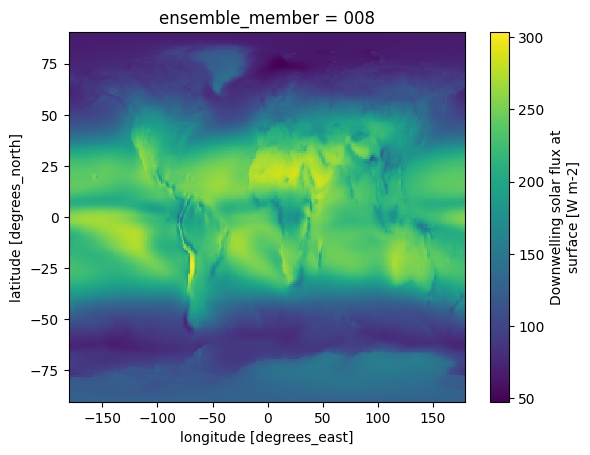

In [12]:
raw_ssp.mean(dim='time').plot()

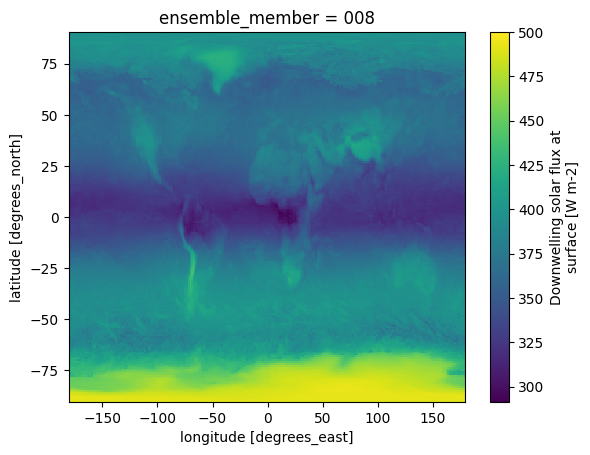

In [19]:
raw_ssp[1:].max(dim='time').plot(vmax=500)

In [17]:
ssp_pt=raw_ssp.sel(lat=0,lon=-150, method='nearest')

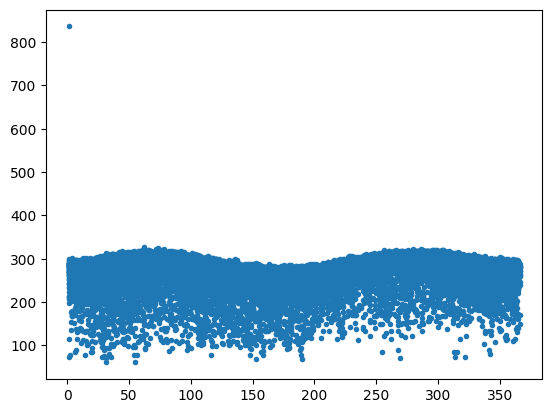

In [18]:
plt.plot(ssp_pt['time.dayofyear'],ssp_pt,'.')

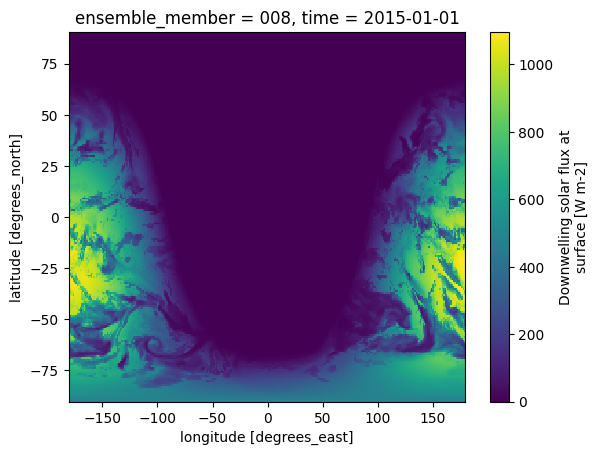

In [22]:
raw_ssp[0,:,:].plot()

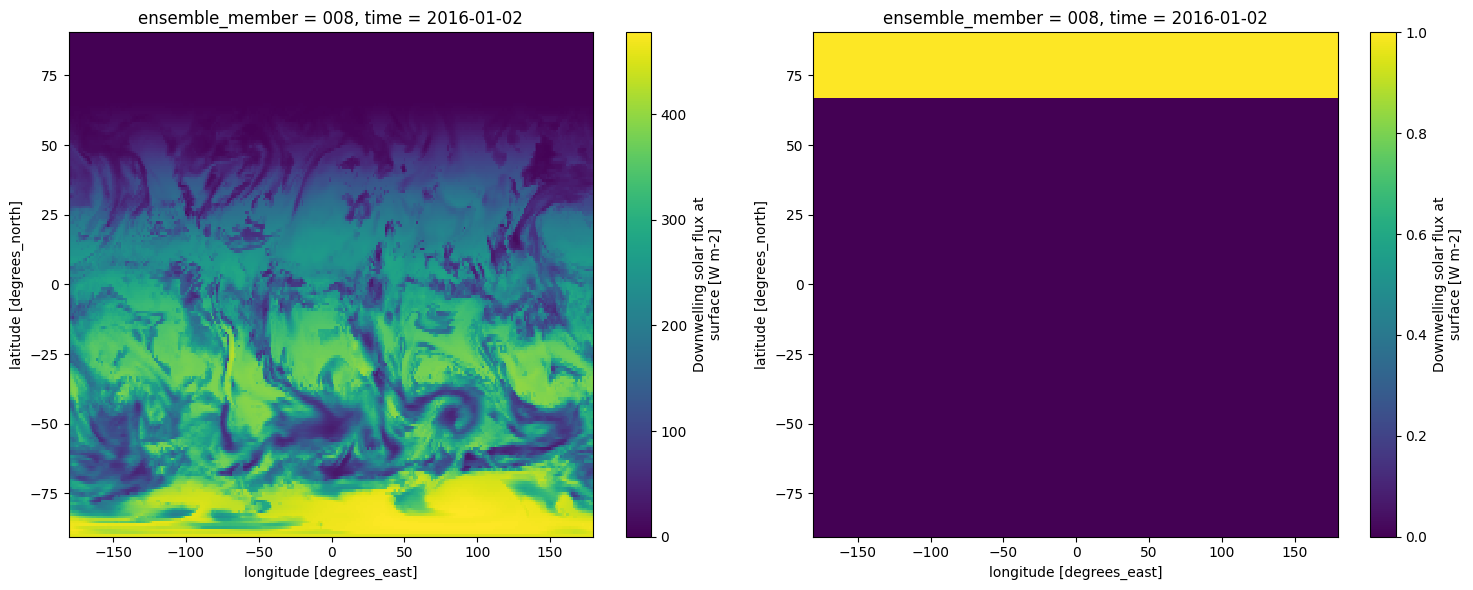

In [5]:
from srm import catalog
import matplotlib.pyplot as plt
var = "rsds"
ssp_ens = "008"

raw_data = catalog.get("CESM2-WACCM").to_xarray()
raw_ssp = raw_data["ssp245"][var].sel(ensemble_member=ssp_ens)

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
raw_ssp[365+1,:,:].plot()
plt.subplot(1,2,2)
(raw_ssp[365+1,:,:]==0).plot()
plt.tight_layout()

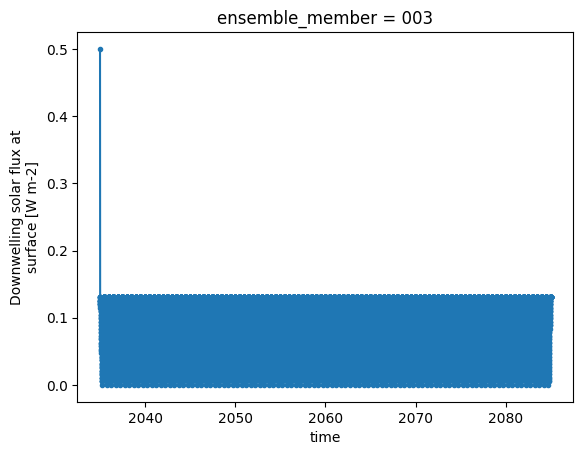

In [18]:
(raw_g6==0).mean(dim=['lat','lon']).plot(marker='.')

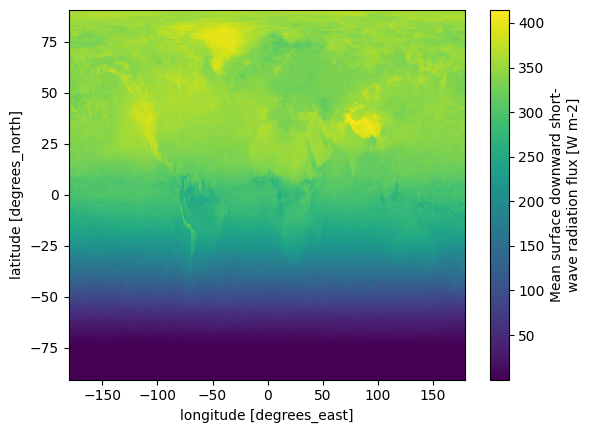

In [43]:
.plot()

(43.0, 46.0)

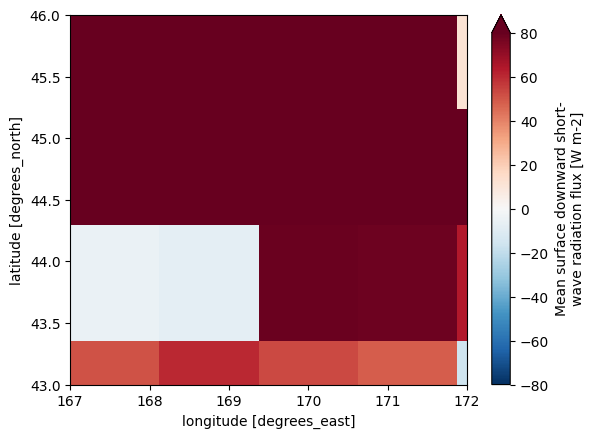

In [76]:
imonth=7
((coarse_debiased_ssp[1:,:,:].where(coarse_debiased_ssp['time.month']==imonth).max(dim='time'))-
 (coarse_obs[1:,:,:].where(coarse_obs['time.month']==imonth).max(dim='time'))).plot(vmax=80)
plt.xlim([167,172])
plt.ylim([43,46])

In [78]:
raw_hist_pt=raw_historical.sel(lat=ilat,lon=ilon, method='nearest').sel(time=slice("1978-01-01","2014-12-31"))
raw_ssp_pt=raw_ssp.sel(lat=ilat,lon=ilon, method='nearest')
coarse_obs_pt=coarse_obs.sel(lat=ilat,lon=ilon, method='nearest')
coarse_debiased_ssp_pt=coarse_debiased_ssp.sel(lat=ilat,lon=ilon, method='nearest')

In [87]:
max_value_obs = coarse_obs.max(dim='lon').groupby('time.dayofyear').max(dim='time')

In [97]:
doy

<xarray.DataArray 'dayofyear' ()> Size: 8B
array(155)
Coordinates:
    dayofyear  int64 8B 155

In [ ]:
for doy in max_value_obs['dayofyear']:
    print(doy.values)
    max_value_obs.sel(dayofyear=doy).plot()

1
2
3
4
5
6
7
8
9
10
11
12
13


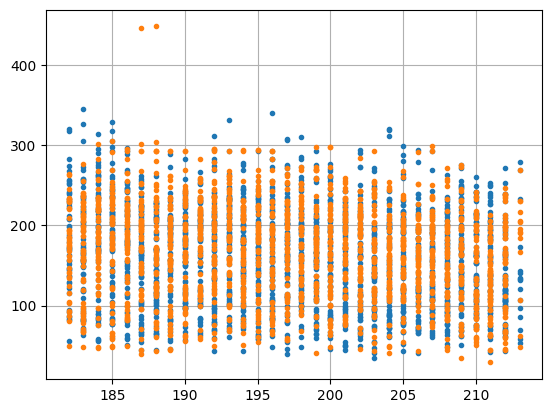

In [79]:
ilat=45
ilon=170
plt.plot(coarse_obs_pt['time.dayofyear'],coarse_obs_pt.where(coarse_obs_pt['time.month']==imonth),'.')
plt.plot(coarse_debiased_ssp_pt['time.dayofyear'],coarse_debiased_ssp_pt.where(coarse_debiased_ssp_pt['time.month']==imonth),'.')
plt.grid()
max_value_obs.sel(day

In [91]:
daily_max=max_value_obs.sel(dayofyear=doy).sel(lat=ilat,method='nearest')

In [93]:
daily_max.load()

<xarray.DataArray 'rsds' ()> Size: 4B
array(379.37488, dtype=float32)
Coordinates:
    lat        float64 8B 44.76
    dayofyear  int64 8B 187
Attributes:
    long_name:   Mean surface downward short-wave radiation flux
    short_name:  msdwswrf
    units:       W m-2

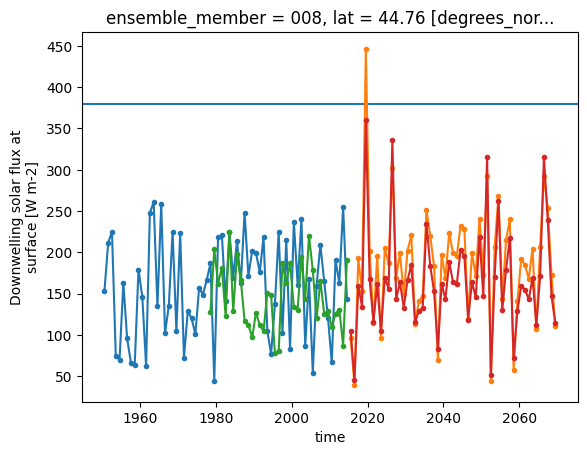

In [94]:
doy=187
plt.axhline(y=daily_max)
coarse_obs_pt.where(coarse_obs_pt['time.dayofyear']==doy,drop=True).plot(marker='.', label='Coarse obs')#,linestyle='none')
coarse_debiased_ssp_pt.where(coarse_debiased_ssp_pt['time.dayofyear']==doy,drop=True).plot(marker='.', label='Coarse SSP')#,linestyle='none')
raw_hist_pt.where(raw_hist_pt['time.dayofyear']==doy,drop=True).plot(marker='.',label='Raw hist')#,linestyle='none')
raw_ssp_pt.where(raw_ssp_pt['time.dayofyear']==doy,drop=True).plot(marker='.', label='Raw SSP')#,linestyle='none')

In [ ]:
(coarse_debiased_ssp[1:,:,:].where(coarse_debiased_ssp['time.month']==2).max(dim='time')).plot(vmax=400)

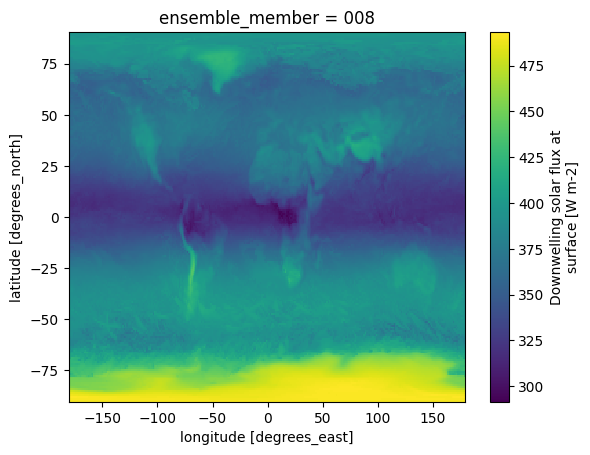

In [22]:
(raw_ssp[1:,:,:].max(dim='time')).plot()